In [11]:
library("tidyverse")
library("GGally")
library("infer")
library("ggcorrplot")

carat     cut   color clarity   depth   table   price       x       y       z 
      0       0       0       0       0       0       0       0       0       0

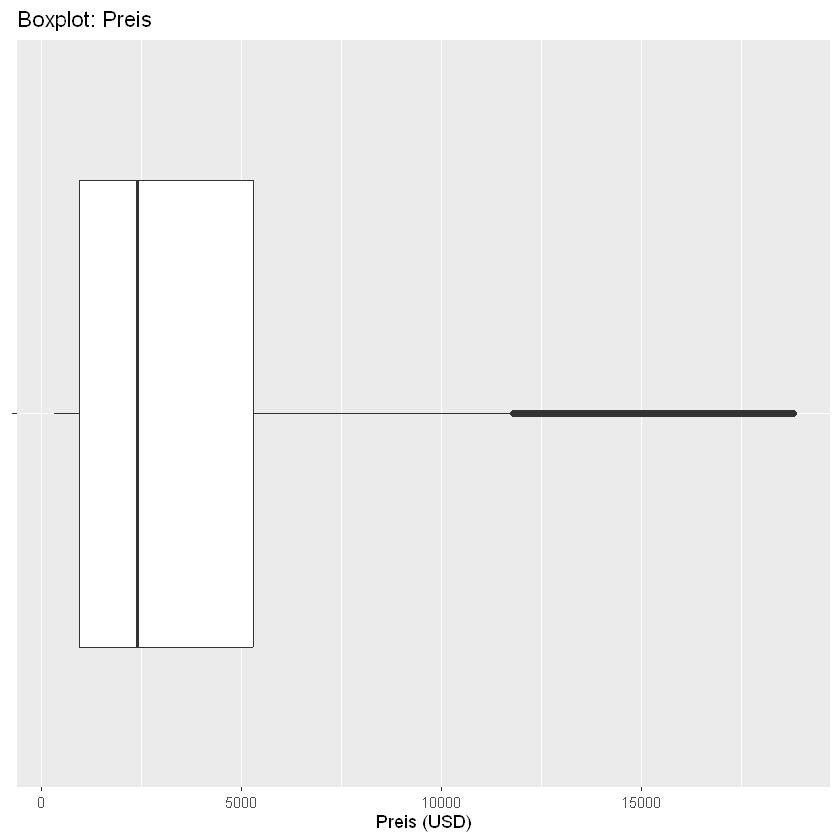

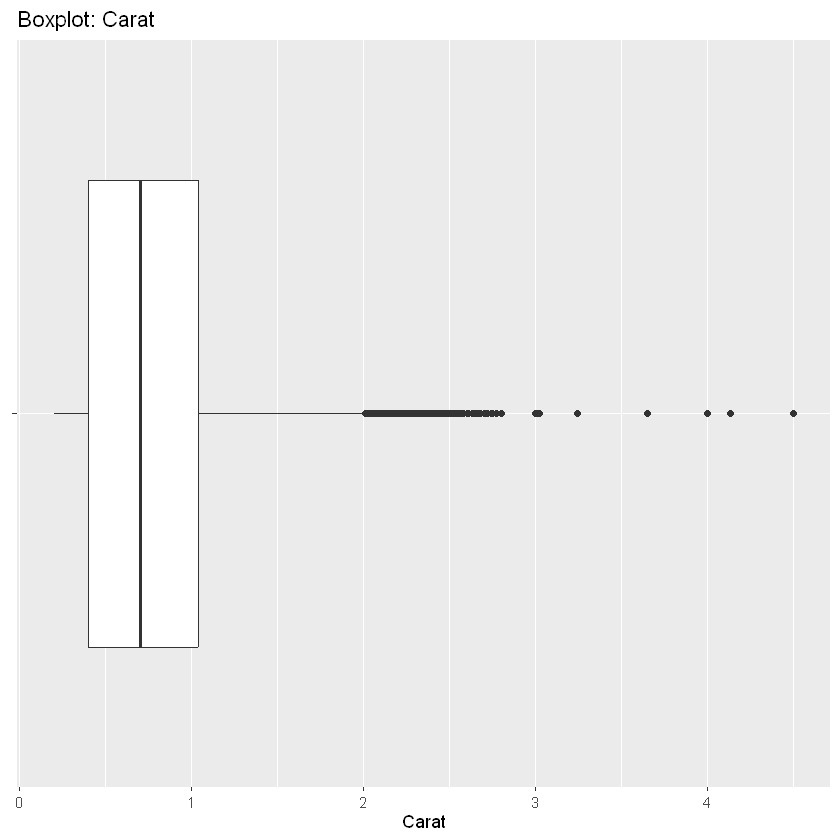

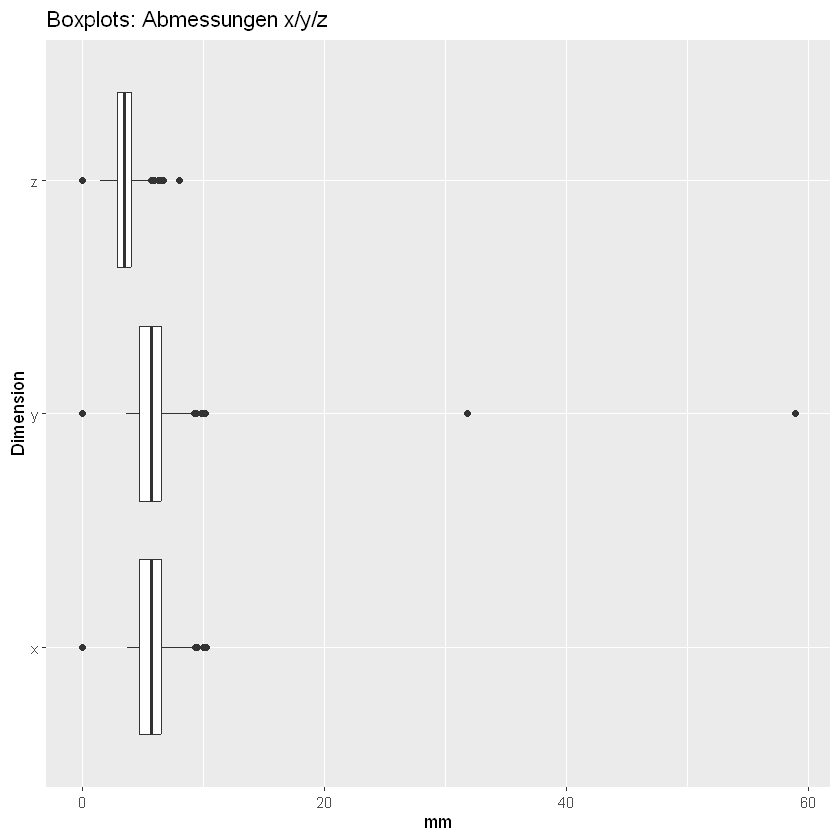

carat,cut,color,clarity,depth,table,price,x,y,z
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1.01,Premium,H,I1,58.1,59,3167,6.66,6.60,0
0.71,Good,F,SI2,64.1,60,2130,0.00,0.00,0
1.00,Very Good,H,VS2,63.3,53,5139,0.00,0.00,0
2.20,Premium,H,SI1,61.2,59,17265,8.42,8.37,0
2.25,Premium,H,SI2,62.8,59,18034,0.00,0.00,0
2.02,Premium,H,VS2,62.7,53,18207,8.02,7.95,0
1.12,Premium,G,I1,60.4,59,2383,6.71,6.67,0
0.71,Good,F,SI2,64.1,60,2130,0.00,0.00,0
1.20,Premium,D,VVS1,62.1,59,15686,0.00,0.00,0


ERROR while rich displaying an object: Error in (function (..., row.names = NULL, check.rows = FALSE, check.names = TRUE, : arguments imply differing number of rows: 1, 0, 10

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .       

<div id="iaymzxymuj" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#iaymzxymuj table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#iaymzxymuj thead, #iaymzxymuj tbody, #iaymzxymuj tfoot, #iaymzxymuj tr, #iaymzxymuj td, #iaymzxymuj th {
  border-style: none;
}

#iaymzxymuj p {
  margin: 0;
  padding: 0;
}

#iaymzxymuj .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  b

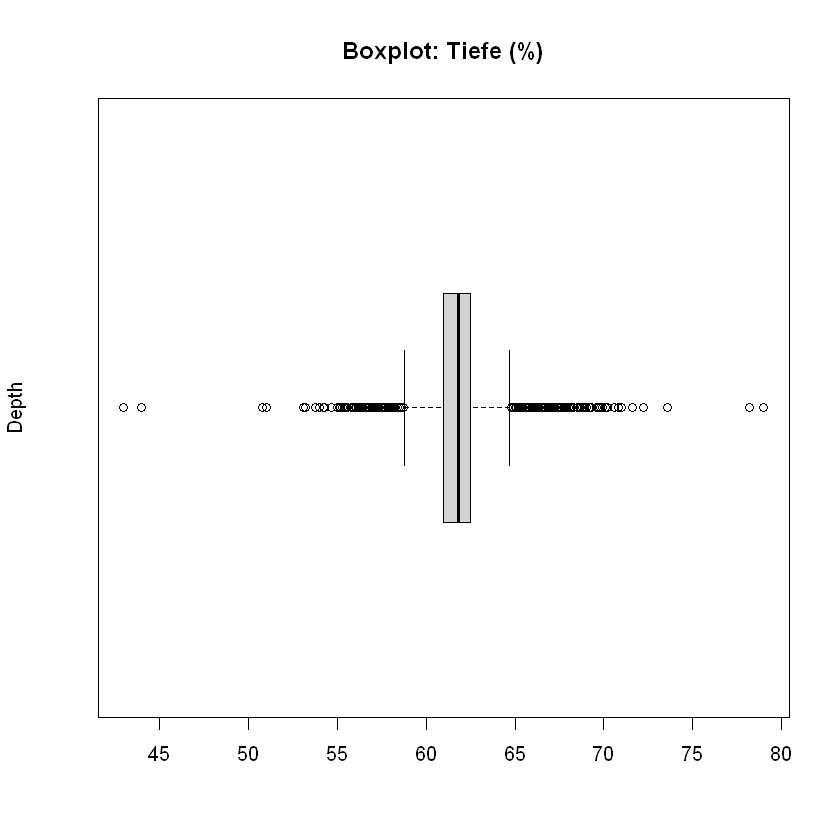

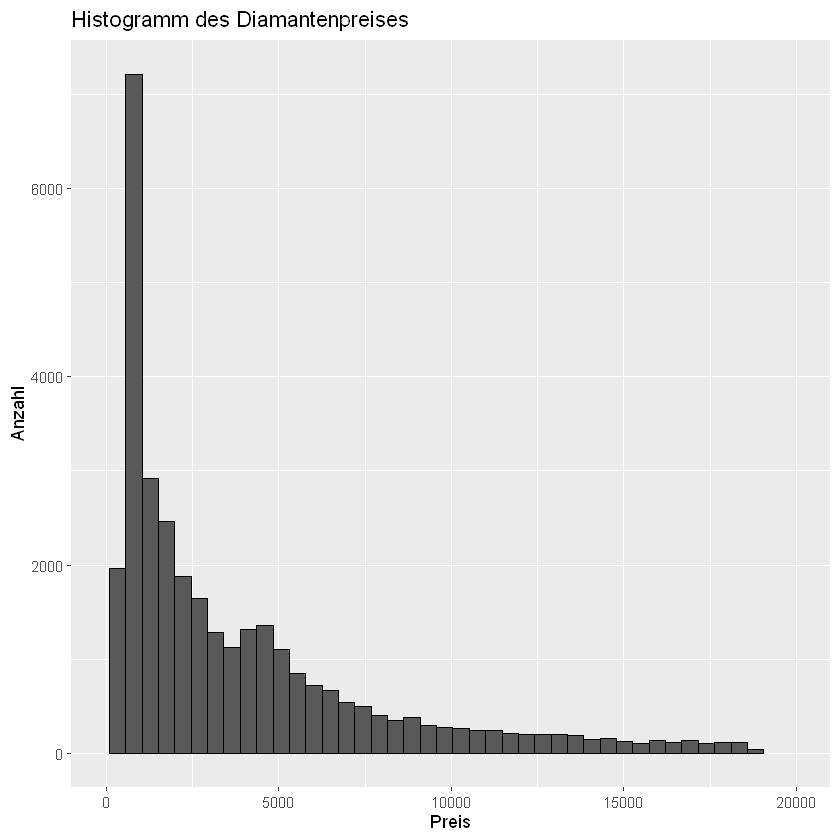

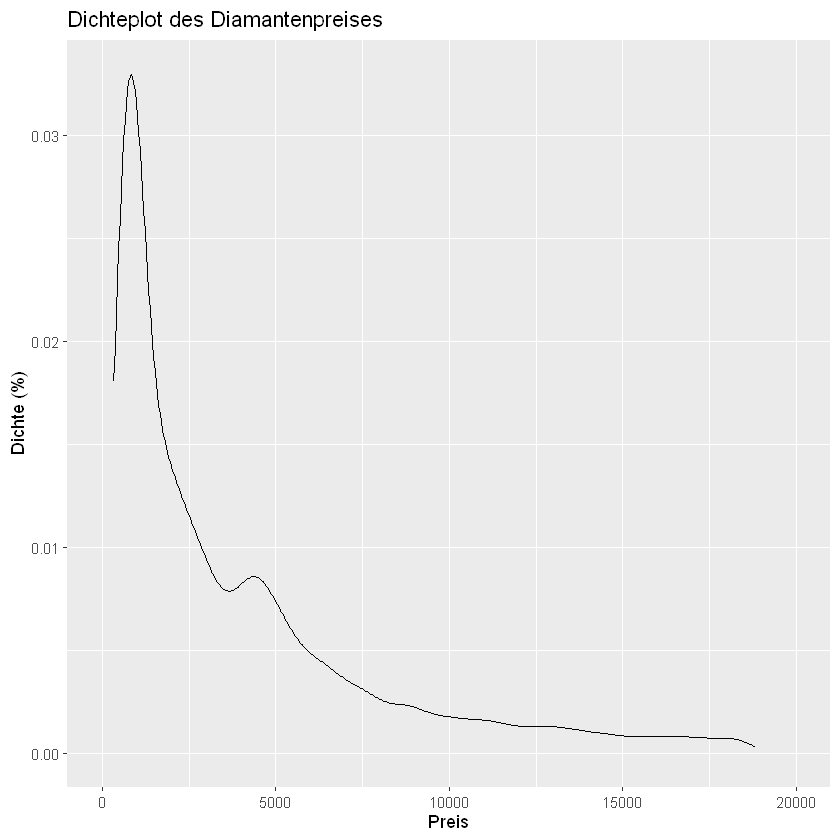

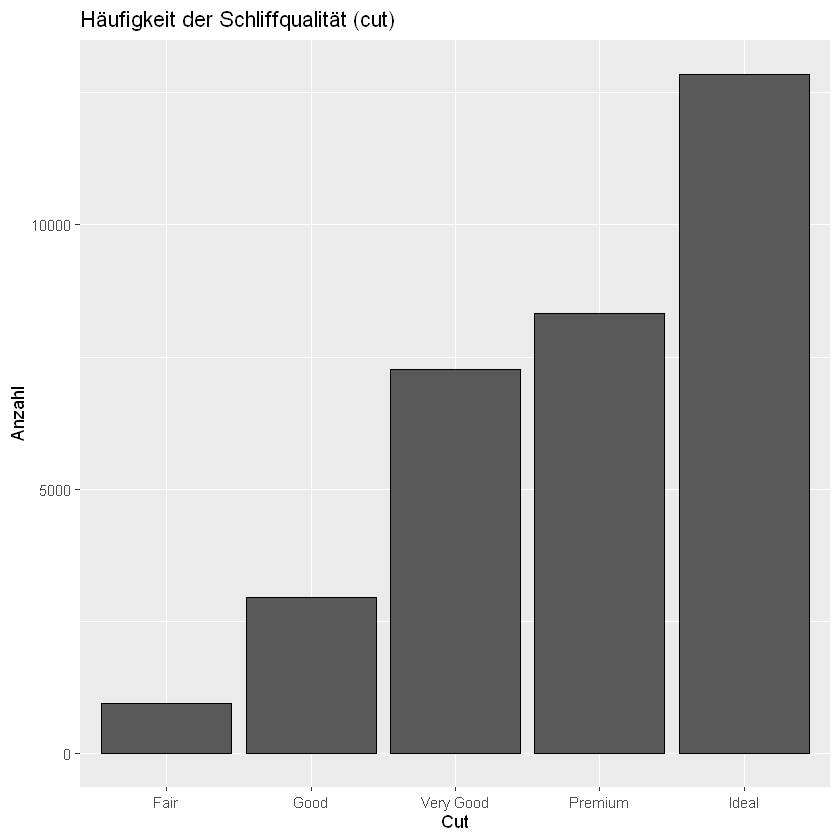

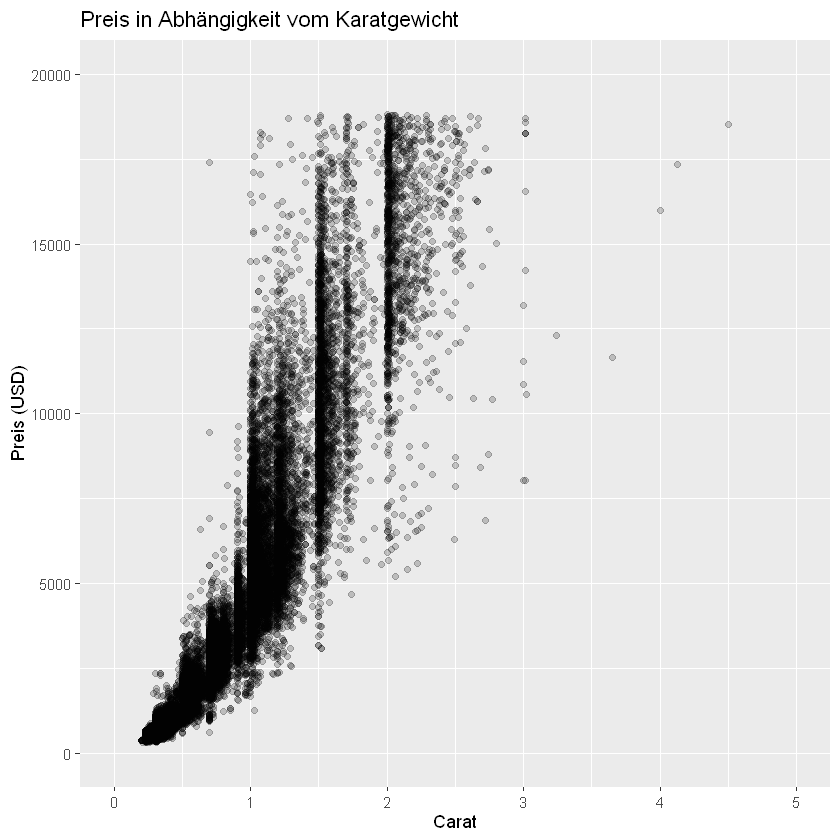

In [2]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(gt)

# \describe{
#   \item{price}{price in US dollars ($326--$18,823)}
#   \item{carat}{weight of the diamond (0.2--5.01)}
#   \item{cut}{quality of the cut (Fair, Good, Very Good, Premium, Ideal)}
#   \item{color}{diamond colour, from D (best) to J (worst)}
#   \item{clarity}{a measurement of how clear the diamond is (I1 (worst), SI2,
#     SI1, VS2, VS1, VVS2, VVS1, IF (best))}
#   \item{x}{length in mm (0--10.74)}
#   \item{y}{width in mm (0--58.9)}
#   \item{z}{depth in mm (0--31.8)}
#   \item{depth}{total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)}
#   \item{table}{width of top of diamond relative to widest point (43--95)}

df <- ggplot2::diamonds
set.seed(123) # sorgt dafür, dass der Zufall immer der selbe ist, macht das script reproduzierbar.

n <- nrow(df)
idx <- sample(n) # daten durchmischen, falls diese nach einer Variale sortiert sind

train_indices <- idx[1:floor(0.6 * n)] # erste 60% des indizes
val_indices <- idx[(floor(0.6 * n) + 1):floor(0.8 * n)]
test_indices <- idx[(floor(0.8 * n) + 1):n]

train_set <- df[train_indices, ]
validation_set <- df[val_indices, ]
test_set <- df[test_indices, ]

# Deskriptive Statistik

colSums(is.na(train_set)) # im diamonds dataset sind keine NA-Einträge vorhanden...

train_set$carat[sample(1:nrow(train_set), 10)] <- NA # ...also setzen wir 10 Werte selbstständig auf NA
train_set$cut[sample(1:nrow(train_set), 10)] <- NA

train_set <- train_set %>% filter(!is.na(price)) # für das spätere lineare Modell, wenn NA vorhanden, wird die Zeile nicht übernommen

# NAs behandeln, da wir nur carat und cut auf NA gesetzt haben, müssen nur diese behandelt werden
median_carat <- median(train_set$carat, na.rm = TRUE) # median aus der carat spalte berechnen ohne die na werte zu beachten
train_set$carat[is.na(train_set$carat)] <- median_carat # diesen median überall dort einsetzten wo wert = NA

mode_cut <- names(sort(table(train_set$cut), decreasing = TRUE))[1]
# table -> zählt häufigkeiten der vorkommenden Kategorien
# Sort -> sortiert das Array absteigend
# names [1] -> gibt den namen der ersten kategorie zurück
train_set$cut[is.na(train_set$cut)] <- mode_cut # modus von cut wird für die NA Werte eingesetzt


# Ausreißer Analyse:

ggplot(train_set, aes(x = price, y = "")) +
  geom_boxplot() +
  labs(title = "Boxplot: Preis", x = "Preis (USD)", y = NULL)
# viele Ausreiße durch hohe Preise vorhanden, werden beibehalten, da diese Preise in der realen Marktbeobachtung relevant sind, Diamanten sind ja Luxusartikel

ggplot(train_set, aes(x = carat, y = "")) +
  geom_boxplot() +
  labs(title = "Boxplot: Carat", x = "Carat", y = NULL)
# Einige sehr große Diamanten vorhanden, meisten sind unter 1, Ausreißer berepresentieren die seleteneren/wertvolleren Diamanten

# par(mfrow = c(1,3))
# The next 3 plots created will be plotted next to each other
# boxplot(train_set$x, main = "x (Länge)", ylab = "mm")
# boxplot(train_set$y, main = "y (Breite)", ylab = "mm")
# boxplot(train_set$z, main = "z (Tiefe)", ylab = "mm")
# Put plotting arrangement back to its original state
# par(mfrow = c(1,1))

train_xyz_long <- train_set %>%
  select(x, y, z) %>%
  pivot_longer(cols = c(x, y, z), names_to = "dimension", values_to = "mm")

ggplot(train_xyz_long, aes(x = mm, y = dimension)) +
  geom_boxplot() +
  labs(title = "Boxplots: Abmessungen x/y/z", x = "mm", y = "Dimension")
# Einzelne sehr große Werte, einige 0 Werte, diese sind nicht realistisch -> sollten eventuell behandelt werden könnten Eingabe- oder Messfehler sein

boxplot(train_set$depth, main = "Boxplot: Tiefe (%)", ylab = "Depth", horizontal = TRUE)
# moderate ausreißer mit plausiblen Werten

# Ausreißer behandeln: Die einzig wirklich auffälligen, die nicht plausibel erscheienn sind x, y, z Werte
# siehe =>
train_set %>% filter(x == 0 | y == 0 | z == 0)

# Deher werden Beobachtungen mit 'unmöglichen' Abmessungen entfernt, da diese wahrscheinlich Messfehler oder Eingabefehler sind
train_set <- train_set %>% filter(x > 0, y > 0, z > 0)


# Grafiken und Tabellen:

# Tabelle:
desc_table <- train_set %>%
  select(price, carat) %>%
  pivot_longer(
    cols = everything(),
    names_to = "Variable",
    values_to = "Wert"
  ) %>%
  group_by(Variable) %>%
  summarise(
    N = n(),
    Min = min(Wert),
    Q1 = quantile(Wert, 0.25),
    Median = median(Wert),
    Mean = mean(Wert),
    Q3 = quantile(Wert, 0.75),
    Max = max(Wert),
    .groups = "drop"
  )

desc_table %>%
  gt() %>%
  tab_header(
    title = "Metrischen Variablen (Carat und Preis)"
  )

# Histogramm:
ggplot(train_set, aes(x = price)) +
  geom_histogram(bins = 40, color = "black") +
  coord_cartesian(xlim = c(0, 20000)) +
  labs(title = "Histogramm des Diamantenpreises", x = "Preis", y = "Anzahl")

# Dichteplot:
ggplot(train_set, aes(x = price)) +
  geom_density(aes(y = after_stat(density * 100))) +
  coord_cartesian(xlim = c(0, 20000)) +
  labs(title = "Dichteplot des Diamantenpreises", x = "Preis", y = "Dichte (%)")
# Die dichte wurde hier auf Prozent pro einheit skaliert, Fläche unter der Kurve = 100


# Balkendiagramm:
ggplot(train_set, aes(x = cut)) +
  geom_bar(color = "black") +
  labs(title = "Häufigkeit der Schliffqualität (cut)", x = "Cut", y = "Anzahl")

# Streudiagramm:
ggplot(train_set, aes(x = carat, y = price)) +
  geom_point(alpha = 0.2) +
  coord_cartesian(xlim = c(0, 5), ylim = c(0, 20000)) +
  labs(title = "Preis in Abhängigkeit vom Karatgewicht", x = "Carat", y = "Preis (USD)")


## Correlation
Below we create a correlation Matrix for all the numeric values from our train set. We see that there is strong postive correlation between the price, carat and the xyz values. While there is very little correlation between price and depth and table. Also the variables carat and x, y and z are postively correlated, which makes perfect sense due to the fact that carat is the weight of the diamond and x, y and z are lenght, width and depth of the diamond (in mm). [Official Documentation](https://ggplot2.tidyverse.org/reference/diamonds.html)

In [17]:
train_set |> head()

carat,cut,color,clarity,depth,table,price,x,y,z
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
0.73,Ideal,I,VS1,60.7,56,2397,5.85,5.81,3.54
0.70,Ideal,G,VS1,60.8,56,3300,5.73,5.80,3.51
0.31,Ideal,D,VS1,61.6,55,713,4.30,4.33,2.66
0.31,Ideal,H,VVS1,62.2,56,707,4.34,4.37,2.71
0.31,Ideal,E,IF,60.9,55,987,4.39,4.41,2.68
0.83,Good,E,SI1,63.7,59,3250,5.95,5.89,3.77


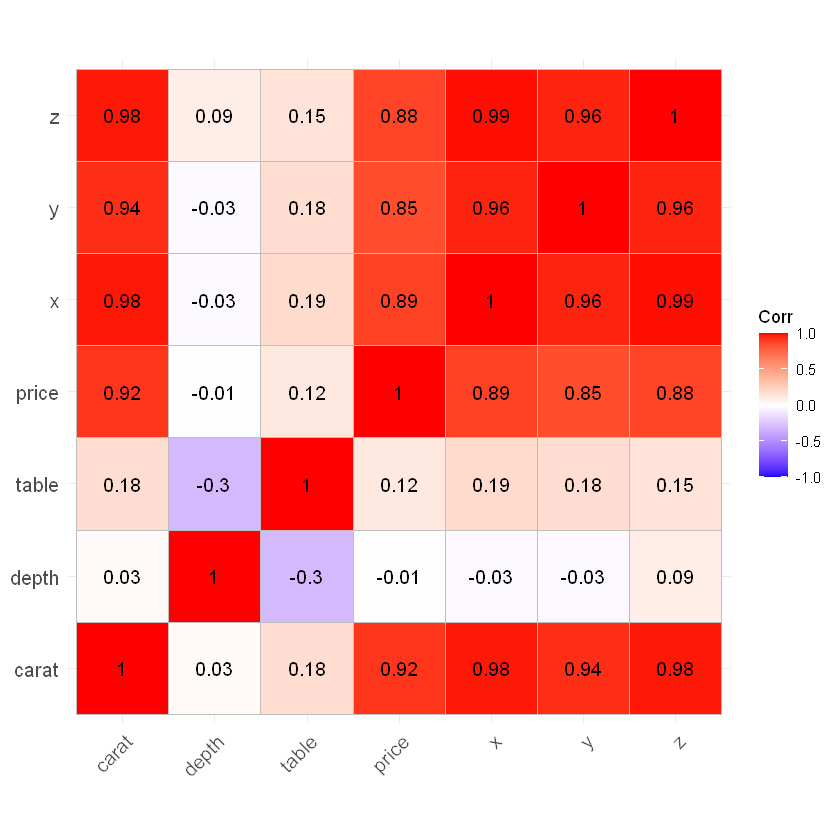

In [ ]:
# Create correlation Matrix
train_corel <- train_set |> 
    select(where(is.numeric)) |> 
    cor() |> 
    round(digits = 2)

# Display correlation plot, easier to us than just correlation Matrix
ggcorrplot(train_corel, lab=TRUE)

## Creating Linear Models
Based on our insights from the previous section we create 4 linear models with the following variables to predict a diamonds price: \
- **model1**: carat, x, y, z (naive approach, just use all variables that have high correlate with price)
- **model2**: carat, depth, table, x, y, z (use all numeric variables)
- **model3**: carat, cut, color, clarity, depth, table, x, y, z (all variables available)
- **model4**: carat, cut, color, clarity (based on [this article](https://4cs.gia.edu/en-us/4cs-of-diamond-quality/) these influence the quality and maybe also the price)

In [ ]:
model1 <- lm(price ~ carat + x + y + z, data = train_set)

coef(model1) |> 
    print() # pretty formatting

(Intercept)       carat           x           y           z 
  3160.2429  11003.3028   -178.2198    232.9362  -2350.5776 


In [21]:
model2 <- lm(price ~ carat + depth + table + x + y + z, data = train_set)

coef(model2) |> 
    print()

(Intercept)       carat       depth       table           x           y 
19026.51077 11089.92323  -163.34826  -102.30781 -1056.44299    87.31062 
          z 
 -683.93844 


In [ ]:
model3 <- lm(price ~ carat + cut + color + clarity + depth + table + x + y + z, data = train_set)

coef(model3) |> 
    print()

(Intercept)       carat       cut.L       cut.Q       cut.C       cut^4 
  845.34380 11617.59530   559.45361  -278.32031   127.66823     5.81841 
    color.L     color.Q     color.C     color^4     color^5     color^6 
-1922.93266  -646.18498  -167.31274    63.99523   -92.49516   -32.86959 
  clarity.L   clarity.Q   clarity.C   clarity^4   clarity^5   clarity^6 
 4056.30440 -1913.52021   953.63033  -354.29652   235.97338    14.49195 
  clarity^7       depth       table           x           y           z 
   87.47761    27.94368   -28.38137  -238.36193   128.28719 -1748.76222 


In [ ]:
model4 <- lm(price ~ carat + cut + color + clarity, data = train_set)

coef(model4) |> 
    print()

(Intercept)       carat       cut.L       cut.Q       cut.C       cut^4 
-3682.93407  8874.28484   684.26600  -311.29462   158.61787    13.20749 
    color.L     color.Q     color.C     color^4     color^5     color^6 
-1868.07145  -593.72868  -174.89205    44.99486   -78.87235   -35.60840 
  clarity.L   clarity.Q   clarity.C   clarity^4   clarity^5   clarity^6 
 4186.70872 -1810.92905   888.89039  -350.51820   218.03961     7.82416 
  clarity^7 
  109.41078 


ERROR: Error in eval(mf, parent.frame()): object 'dein_datensatz' not found
